In [1]:
from pydantic import BaseModel, Field

# 그래프 상태 정의
# - 워크플로우 전체에서 공유되는 데이터 구조
class EmotionBotState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 메시지")
    emotion: str = Field(default="", description="분석된 감정")
    response: str = Field(default="", description="최종 응답 메시지")

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [3]:
from typing import Dict, Any, Literal
from langchain_core.messages import SystemMessage, HumanMessage

# LLM 기반 감정 분석 노드
def analyze_emotion(state: EmotionBotState) -> Dict[str, Any]:
    message = state.user_message
    print(f"LLM 감정 분석 중: '{message}'")

    messages = [
        SystemMessage(
            content="당신은 감정 분석 전문가입니다. 사용자의 메시지를 분석하여 'positive', 'negative', 'neutral' 중 하나로 감정을 분류해주세요. 답변은 반드시 하나의 단어만 출력하세요."
        ),
        HumanMessage(content=f"다음 메시지의 감정을 분석해주세요: '{message}'"),
    ]

    response = model.invoke(messages)
    emotion = response.content.strip().lower()

    # 유효성 검사
    if emotion not in ["positive", "negative", "neutral"]:
        emotion = "neutral"

    print(f"LLM 감정 분석 결과: {emotion}")
    return {"emotion": emotion}

In [27]:
import random

# 긍정적 응답 생성
def generate_positive_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = "😀" # 미소
    return {"response": responses}

In [28]:

# 부정적 응답 생성
def generate_negative_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = "😟" # 걱정
    return {"response": responses}

In [29]:
# 중립적 응답 생성
def generate_neutral_response(state: EmotionBotState) -> Dict[str, Any]:
    responses = "😑" # 무표정
    return {"response": responses}

In [30]:
# 조건부 라우팅 함수
# - 감정 분석 결과에 따라 다음 노드 결정
def route_by_emotion(
    state: EmotionBotState,
) -> Literal["positive_response", "negative_response", "neutral_response"]:
    emotion = state.emotion
    print(f"라우팅: {emotion}")

    if emotion == "positive":
        return "positive_response"
    elif emotion == "negative":
        return "negative_response"
    else:
        return "neutral_response"

In [31]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(EmotionBotState)

# 노드 추가 
# - 각 처리 단계를 그래프에 등록
graph_builder.add_node("analyze_emotion", analyze_emotion)
graph_builder.add_node("positive_response", generate_positive_response)
graph_builder.add_node("negative_response", generate_negative_response)
graph_builder.add_node("neutral_response", generate_neutral_response)

In [ ]:
# 시작 엣지 설정
graph_builder.add_edge(START, "analyze_emotion")

# 조건부 엣지 설정
graph_builder.add_conditional_edges(
    "analyze_emotion",
    route_by_emotion,
    {
        "positive_response": "positive_response",
        "negative_response": "negative_response",
        "neutral_response": "neutral_response",
    },
)

# 종료 엣지 설정
graph_builder.add_edge("positive_response", END)
graph_builder.add_edge("negative_response", END)
graph_builder.add_edge("neutral_response", END)

In [33]:
graph = graph_builder.compile()

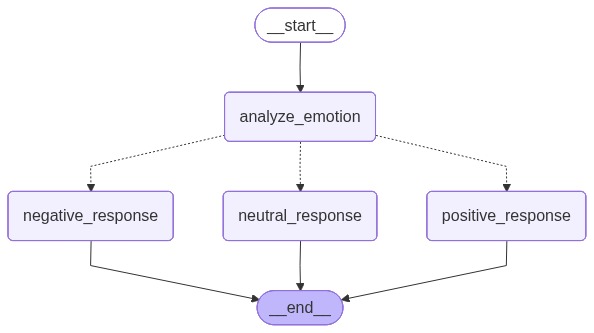

In [34]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [54]:
# message = "너무 기뻐요!"
# message = "너무 슬퍼요!"
message = "밥 먹었어요?"

In [55]:
state = EmotionBotState(user_message=message)
response = graph.invoke(state)

LLM 감정 분석 중: '밥 먹었어요?'
LLM 감정 분석 결과: neutral
라우팅: neutral


In [56]:
response

{'user_message': '밥 먹었어요?', 'emotion': 'neutral', 'response': '😑'}